# Wireless Coverage — Part 2: LiDAR Surfaces (DSM + DTM) → CHM

**Produce the surface *products* from the LiDAR point cloud — a Digital Surface Model and a bare-earth Digital Terrain Model as reusable GeoTIFF tiles — then derive the Canopy Height Model from them.**

Where Part 1 kept only the CHM, Part 2 **persists DSM and DTM** as GeoTIFF tiles on the Volume: downstream coverage analytics (antenna line-of-sight, `rst_viewshed`) consume *surface rasters*, not point clouds. We also contrast two bare-earth grounds:

- **Binned DTM** — `min` z of ground returns per pixel (fast, may leave tiny gaps where no ground return landed).
- **TIN DTM** — a Delaunay triangulation of the ground returns (`rst_dtmfromgeoms_agg`), barycentrically interpolated → gap-free bare earth. Points are built product-natively with `st_makepoint(x, y, z)`.

Same per-tile distributed binning as Part 1.

> **Runtime.** Runs on **Databricks Serverless environment 5** — the [lightweight tier](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers) (pure Python/PySpark, no JAR or GDAL init script). `DECIMATE=1` keeps **every** return (~830 M over San Francisco) — an honest big-data run; raise `DECIMATE` (e.g. 10) for a fast coarse pass while iterating.

---

**Last Update:** September 18, 2026


## Install GeoBrix

In [0]:
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix[light_env5,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env5,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

## Imports and registration

In [0]:
import warnings
warnings.filterwarnings("ignore")
from pyspark.sql import functions as F

from databricks.labs.gbx.pyrx import functions as rx
from databricks.labs.gbx.ds.register import register
from databricks.labs.gbx.vizx import plot_raster, plot_file
from databricks.labs.gbx.sample.lidar import aoi_lonlat_to_3857, lonlat_to_3857

register(spark)


def _persist(df, name):
    """Write a binned-surface DataFrame to a PERMANENT table you own
    (``CATALOG.SCHEMA.TABLE_PREFIX_<name>``) and return it read back, so downstream
    cells read stored tiles instead of re-binning the point cloud. ``FORCE_RELOAD``
    rebuilds; otherwise an existing table is reused. Permanent tables persist
    across sessions and clusters."""
    tbl = f"{CATALOG}.{SCHEMA}.{TABLE_PREFIX}_{name}"
    if FORCE_RELOAD or not spark.catalog.tableExists(tbl):
        df.write.mode("overwrite").saveAsTable(tbl)
    return spark.table(tbl)

## Parameters

In [0]:
SF_AOI  = (-122.55, 37.70, -122.35, 37.85)          # all of San Francisco (lon/lat)
LAZ_DIR = "/Volumes/geospatial_docs/wireless_coverage/data/lidar/sf/laz"

# --- persistence: surface products are PERMANENT tables you own ---
CATALOG      = "geospatial_docs"                     # <- set to a catalog you can write to
SCHEMA       = "geobrix"                             # <- set to a schema you can write to
TABLE_PREFIX = "wc_surface"                          # tables: <CATALOG>.<SCHEMA>.wc_surface_{dsm,dtm,chm}

SRID    = 3857
PIXEL_M = 1.0
TILE_M  = 1024.0
TPX     = int(TILE_M / PIXEL_M)
DECIMATE = 1                                          # keep every Nth point (raise for a faster coarse pass)
FORCE_RELOAD = False                                  # True to rebuild the surface tables (else reuse)

# Optional: also export the surfaces to GeoTIFF files on a Volume (off by default).
WRITE_GEOTIFF = False
OUT_DIR = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/lidar-surfaces"

X0, Y0, X1, Y1 = aoi_lonlat_to_3857(*SF_AOI)
print(f"AOI 3857 x[{X0:.0f},{X1:.0f}] y[{Y0:.0f},{Y1:.0f}] | tile {TILE_M:.0f}m={TPX}px | decimate {DECIMATE}")

AOI 3857 x[-13642204,-13619940] y[4537132,4558257] | tile 1024m=1024px | decimate 1


## Load the point cloud and assign tiles

Same as Part 1: one row per return via the GeoBrix `lidar_gbx` reader (recurses the project subfolders), clipped to the AOI and stamped with its 1024 m tile + that tile's absolute extent (EPSG:3857).

In [0]:
pts = (spark.read.format("lidar_gbx").option("decimate", str(DECIMATE)).load(LAZ_DIR)
       .where((F.col("x") >= X0) & (F.col("x") <= X1) & (F.col("y") >= Y0) & (F.col("y") <= Y1))
       .withColumn("tx", F.floor((F.col("x") - F.lit(X0)) / F.lit(TILE_M)).cast("int"))
       .withColumn("ty", F.floor((F.col("y") - F.lit(Y0)) / F.lit(TILE_M)).cast("int"))
       .withColumn("t_xmin", F.lit(X0) + F.col("tx") * F.lit(TILE_M))
       .withColumn("t_ymin", F.lit(Y0) + F.col("ty") * F.lit(TILE_M))
       .withColumn("t_xmax", F.col("t_xmin") + F.lit(TILE_M))
       .withColumn("t_ymax", F.col("t_ymin") + F.lit(TILE_M)))

## Bin the surfaces — DSM (all returns, `max`) and DTM (ground, `min`)

Each surface is one GeoBrix `bin_points_tiled` per tile — memory bounded by the raster grid
(W×H), not the point count, so full-density LiDAR bins without OOM. We **persist DSM and DTM to
permanent tables** you own (`CATALOG.SCHEMA.wc_surface_*`): downstream coverage analytics consume
*surface rasters*, and a governed Delta table of tiles is the reusable product (queryable, joinable,
survives the session). `FORCE_RELOAD=False` reuses existing tables. (An optional GeoTIFF export to a
Volume is available via `WRITE_GEOTIFF`.)

In [0]:
# Bounded binning (memory ∝ grid, not points): DSM = max z (all returns),
# DTM = min z (ground, class 2). Persist each to a permanent table you own.
dsm = rx.bin_points_tiled(
    pts, x="x", y="y", z="z", by=["tx", "ty"],
    xmin="t_xmin", ymin="t_ymin", xmax="t_xmax", ymax="t_ymax",
    width=TPX, height=TPX, srid=SRID, stat="max").withColumnRenamed("tile", "dsm")
dtm = rx.bin_points_tiled(
    pts.where(F.col("classification") == 2), x="x", y="y", z="z", by=["tx", "ty"],
    xmin="t_xmin", ymin="t_ymin", xmax="t_xmax", ymax="t_ymax",
    width=TPX, height=TPX, srid=SRID, stat="min").withColumnRenamed("tile", "dtm")

dsm = _persist(dsm, "dsm")
dtm = _persist(dtm, "dtm")
print(f"DSM {dsm.count()} | DTM {dtm.count()} tiles -> {CATALOG}.{SCHEMA}.{TABLE_PREFIX}_*")

DSM 381 | DTM 336 tiles -> geospatial_docs.geobrix.wc_surface_*


## Write DSM and DTM as GeoTIFF products

The GeoBrix `gtiff_gbx` writer takes exactly `(source, tile)` and emits `<source>.tif`. We name each tile `dsm_<tx>_<ty>` / `dtm_<tx>_<ty>`. These tiles are the reusable surface products the later coverage notebooks read.

In [0]:
# Optional: export the surface tables to GeoTIFF files (for external raster consumers).
# The permanent tables above are the primary, reusable products; this is just an export.
if WRITE_GEOTIFF:
    def _prods(df, col, kind):
        return df.select(F.concat_ws("_", F.lit(kind), "tx", "ty").alias("source"),
                         F.col(col).alias("tile"))
    _prods(dsm, "dsm", "dsm").write.format("gtiff_gbx").mode("overwrite").save(f"{OUT_DIR}/dsm")
    _prods(dtm, "dtm", "dtm").write.format("gtiff_gbx").mode("overwrite").save(f"{OUT_DIR}/dtm")
    print("exported DSM + DTM GeoTIFFs ->", OUT_DIR)
else:
    print("GeoTIFF export off (WRITE_GEOTIFF=False); surfaces are the permanent tables.")

GeoTIFF export off (WRITE_GEOTIFF=False); surfaces are the permanent tables.


## Bare-earth ground: binned vs TIN (on a sample tile)

The binned DTM takes the `min` ground return per pixel; a **TIN** triangulates the ground returns and interpolates a continuous, gap-free surface. A Delaunay TIN must hold **all** its input points in memory to triangulate — unlike the binned DTM, whose memory is bounded by the raster grid — so at full density (`DECIMATE=1`) a single tile's ground returns can exceed a worker. We therefore **thin the tile's ground returns to a bounded sample** (`TIN_MAX_PTS`) for this contrast; a bare-earth TIN is near-identical from a representative subset. We build Z-valued points with the Databricks Product functions `st_makepoint(x, y, z)` and `st_asbinary(...)` → WKB POINT Z, feed them to the GeoBrix `rst_dtmfromgeoms_agg` aggregator, and compare both grounds with the `plot_raster` helper. Shown on one Golden Gate Park tile.

sample tile tx=6 ty=9 | 1798727 ground pts -> TIN on ~150000 (frac=0.083)


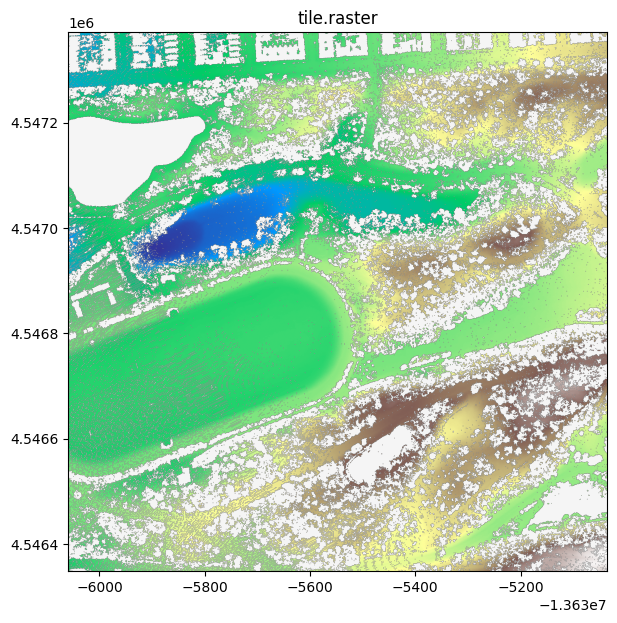

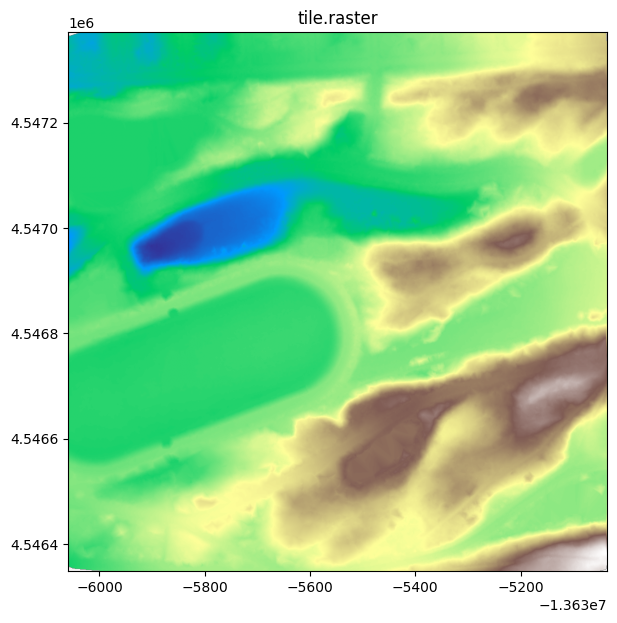

In [0]:
_gx, _gy = lonlat_to_3857(-122.486, 37.769)     # Golden Gate Park
_tx, _ty = int((_gx - X0) // TILE_M), int((_gy - Y0) // TILE_M)
_sel = (F.col("tx") == _tx) & (F.col("ty") == _ty)

# A Delaunay TIN must hold ALL its input points in memory to triangulate — unlike the
# binned DTM (memory ∝ grid) — so at DECIMATE=1 a full-density tile can OOM a worker.
# Persist this tile's ground returns once (reused via FORCE_RELOAD), then thin to a
# bounded sample for the TIN: a bare-earth TIN is near-identical from a representative
# subset (standard LiDAR TIN practice).
TIN_MAX_PTS = 150_000
ground = _persist(
    pts.where((F.col("classification") == 2) & _sel)
       .select("tx", "ty", "t_xmin", "t_ymin", "t_xmax", "t_ymax", "x", "y", "z"),
    "ground_ggp",
)
n_ground = ground.count()
frac = min(1.0, TIN_MAX_PTS / n_ground) if n_ground else 1.0
ground_s = (ground.sample(withReplacement=False, fraction=frac, seed=42)
              .withColumn("pt", F.expr("st_asbinary(st_makepoint(x, y, z))")))
dtm_tin = ground_s.groupBy("tx", "ty").agg(
    rx.rst_dtmfromgeoms_agg("pt", F.lit(None), F.lit(0.0), F.lit(0.0),
                            "t_xmin", "t_ymin", "t_xmax", "t_ymax",
                            F.lit(TPX), F.lit(TPX), F.lit(SRID)).alias("dtm_tin"))
tin_t = dtm_tin.first()
binned_t = dtm.where(_sel).first()
print(f"sample tile tx={_tx} ty={_ty} | {n_ground} ground pts -> TIN on ~{min(n_ground, TIN_MAX_PTS)} (frac={frac:.3f})")
if binned_t: plot_raster(binned_t["dtm"]["raster"], cmap="terrain", fig_w=7, fig_h=7)   # binned ground
if tin_t:    plot_raster(tin_t["dtm_tin"]["raster"], cmap="terrain", fig_w=7, fig_h=7)   # TIN ground

## CHM from the surface tables, then persist it

Difference the persisted surfaces with the GeoBrix `rst_chm` (DSM − DTM, clamped ≥ 0), persist
the CHM to `CATALOG.SCHEMA.wc_surface_chm`, and preview the sample tile with `plot_raster`.

336 CHM tiles -> geospatial_docs.geobrix.wc_surface_chm


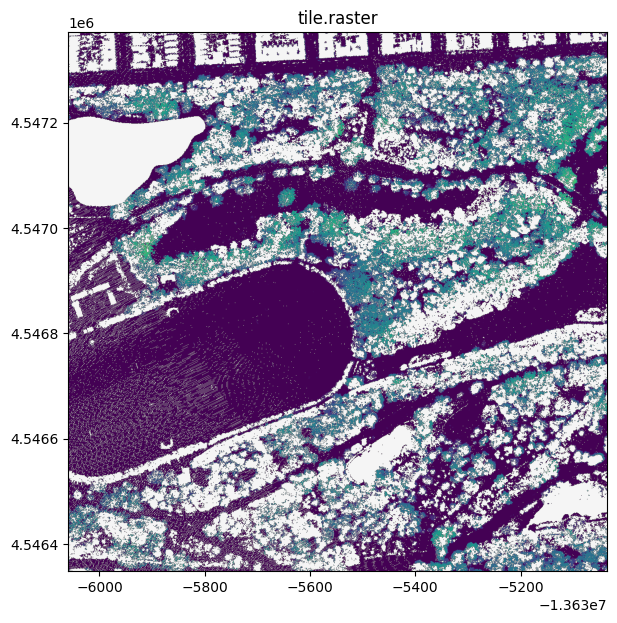

In [0]:
chm = (dsm.join(dtm, ["tx", "ty"]).select("tx", "ty", rx.rst_chm("dsm", "dtm").alias("chm")))
chm = _persist(chm, "chm")
print(f"{chm.count()} CHM tiles -> {CATALOG}.{SCHEMA}.{TABLE_PREFIX}_chm")
chm_t = chm.where(_sel).first()
if chm_t:
    plot_raster(chm_t["chm"]["raster"], cmap="viridis", fig_w=7, fig_h=7)

if WRITE_GEOTIFF:
    (chm.select(F.concat_ws("_", F.lit("chm"), "tx", "ty").alias("source"),
                F.col("chm").alias("tile"))
        .write.format("gtiff_gbx").mode("overwrite").save(f"{OUT_DIR}/chm"))
    print("exported CHM GeoTIFFs ->", OUT_DIR)

## Summary

From one classified LiDAR point cloud we produced **DSM, bare-earth DTM, and CHM** as reusable GeoTIFF tiles over San Francisco, compared a **binned vs. TIN** bare earth (`rst_dtmfromgeoms_agg`, product-native `st_makepoint` points), and derived CHM with `rst_chm`. These surface products are the inputs for the coverage analytics in later parts (antenna siting, line-of-sight via `rst_viewshed`).